# 1. Changing the Error Level of Tensor Flow

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
# input

input = Input(shape =(28,28,1))

# 1st Conv Block

x = Conv2D (filters =16, kernel_size =3, padding ='same', activation='relu')(input)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 2nd Conv Block

x = Conv2D (filters =32, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)


x = Flatten()(x)
x = Dense(units = 16, activation ='relu')(x)
output = Dense(units = 10, activation ='softmax')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1568)              0     

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [5]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=3,
)

Fit model on training data
Epoch 1/3
938/938 [==============================] - 9s 9ms/step - loss: 0.7084 - sparse_categorical_accuracy: 0.8325
Epoch 2/3
938/938 [==============================] - 9s 10ms/step - loss: 0.0938 - sparse_categorical_accuracy: 0.9741
Epoch 3/3
938/938 [==============================] - 9s 10ms/step - loss: 0.0640 - sparse_categorical_accuracy: 0.9820


# Saving the model for later user

In [6]:
model.save("trained_models/")

INFO:tensorflow:Assets written to: trained_models/assets


INFO:tensorflow:Assets written to: trained_models/assets


# Loading the model

In [8]:
from tensorflow.keras import models

trained_model = keras.models.load_model("trained_models/")


In [9]:
trained_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1568)              0     

In [10]:
import numpy
predictions = trained_model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 1s 2ms/step
matched numbers : 9837
non matched numbers : 163


In [11]:
import numpy
predictions = model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 1s 2ms/step
matched numbers : 9837
non matched numbers : 163


# Plotting Confusion Matrix and Saving the Image

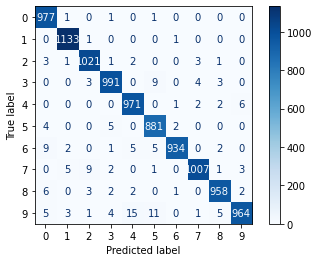

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_pred = predicted_number
y_test = y_test
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.jpg")
plt.show()

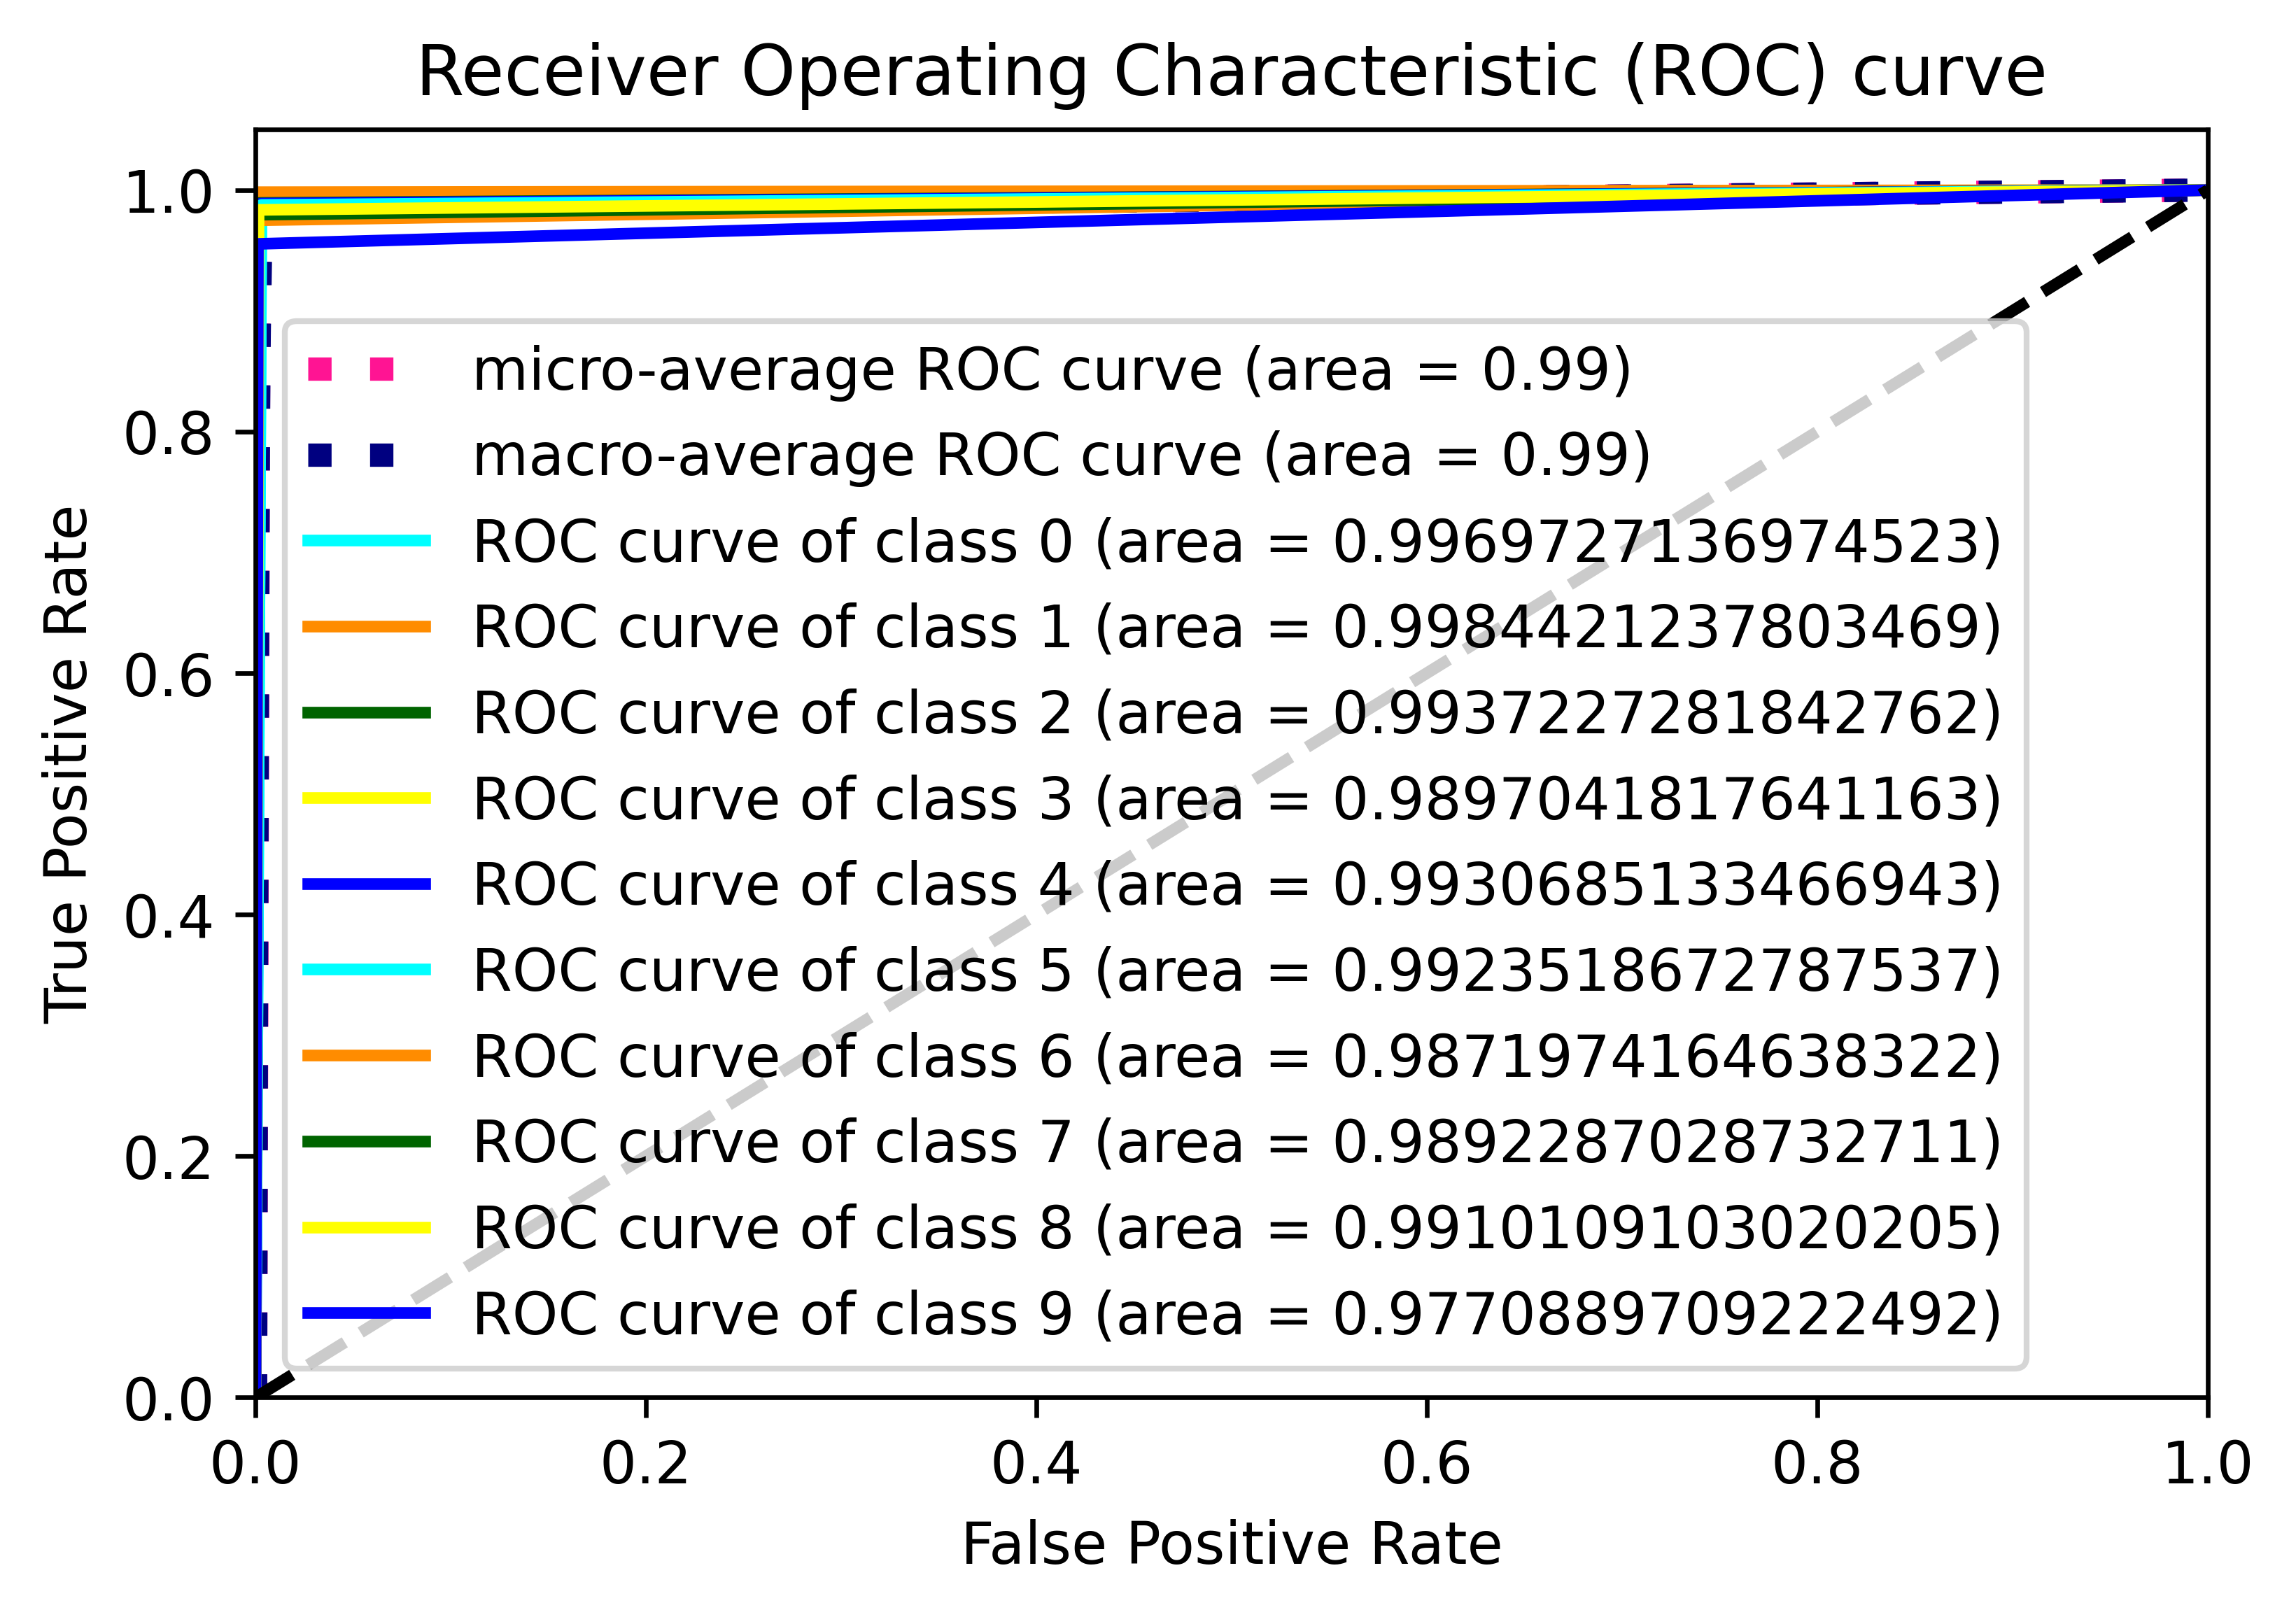

In [17]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 2
plt.plot(fpr["micro"], tpr["micro"],
label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
color="deeppink", linestyle=":", linewidth=4,)

plt.plot(fpr["macro"], tpr["macro"],
label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
color="navy", linestyle=":", linewidth=4,)

colors = cycle(["aqua", "darkorange", "darkgreen", "yellow", "blue"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"ROC curve of class {i} (area = {roc_auc[i]})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,label=string_label,)

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.savefig("ROC2.jpg")
plt.legend()

### Doesnot saves the label of ROC

In [18]:
%matplotlib inline

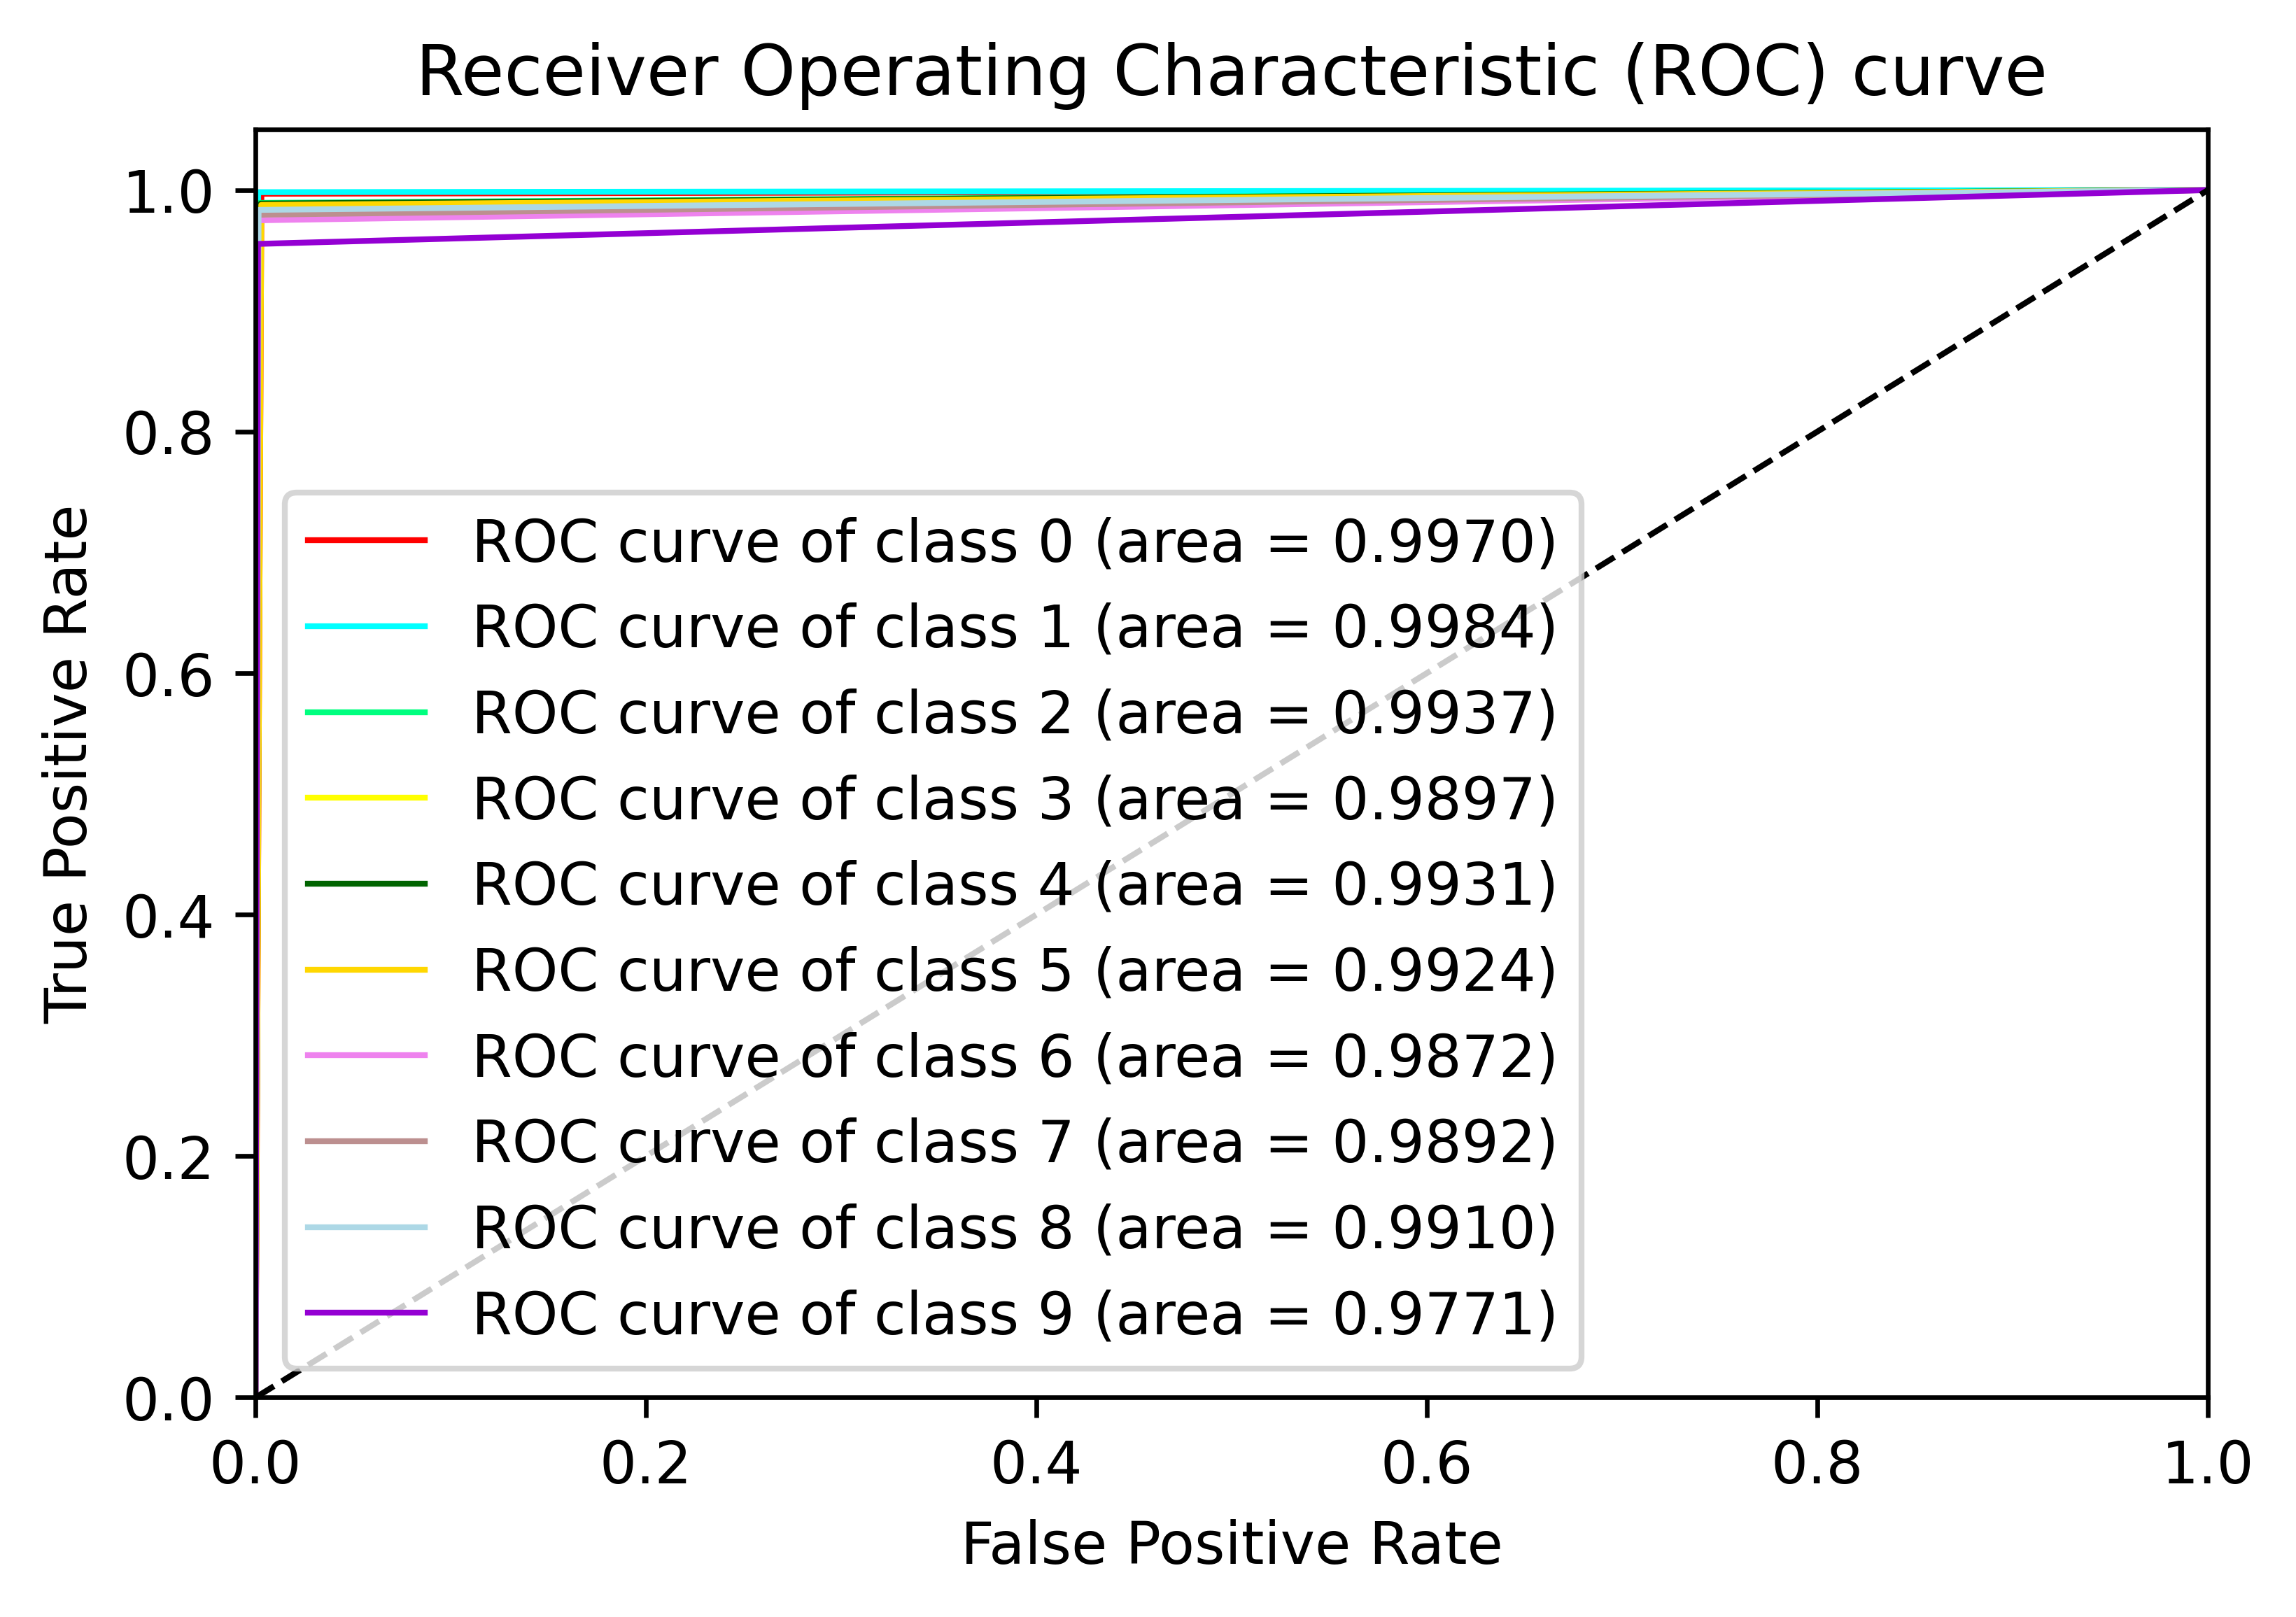

In [46]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



n_classes = len(np.unique(y_test))
y_labelized_test = label_binarize(y_test, classes=np.arange(n_classes))
y_labelized_pred = label_binarize(predicted_number, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
thresholds = dict()
for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(y_labelized_test[:, i], y_labelized_pred[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_labelized_test.ravel(), y_labelized_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
#plt.figure(figsize=(10,5))
plt.figure(dpi=600)
lw = 1


colors = cycle(["red", "cyan", "springgreen", "yellow", "darkgreen", "gold", "violet", "rosybrown", "lightblue", "darkviolet"])
for i, color in zip(range(n_classes), colors):
    #print(i, roc_auc)
    string_label = f"ROC curve of class {i} (area = {roc_auc[i]:0.4f})"
    plt.plot(fpr[i], tpr[i], color=color, 
             lw=lw,label=string_label)

plt.plot([0, 1], [0, 1], "k--", lw=lw,)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) curve")
plt.legend()
plt.savefig("ROC3.jpg", bbox_inches="tight", dpi=1000)

In [35]:
help(plt.plot)

Help on function plot in module matplotlib.pyplot:

plot(*args, scalex=True, scaley=True, data=None, **kwargs)
    Plot y versus x as lines and/or markers.
    
    Call signatures::
    
        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)
    
    The coordinates of the points or line nodes are given by *x*, *y*.
    
    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.
    
    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses
    
    You can use `.Line2D` properties as keyword arguments for more
    control on the appearance. Line properties and *fmt* can be mixed.
    The f

In [35]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [48]:
help(f1_score)

Help on function f1_score in module sklearn.metrics._classification:

f1_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')
    Compute the F1 score, also known as balanced F-score or F-measure.
    
    The F1 score can be interpreted as a harmonic mean of the precision and
    recall, where an F1 score reaches its best value at 1 and worst score at 0.
    The relative contribution of precision and recall to the F1 score are
    equal. The formula for the F1 score is::
    
        F1 = 2 * (precision * recall) / (precision + recall)
    
    In the multi-class and multi-label case, this is the average of
    the F1 score of each class with weighting depending on the ``average``
    parameter.
    
    Read more in the :ref:`User Guide <precision_recall_f_measure_metrics>`.
    
    Parameters
    ----------
    y_true : 1d array-like, or label indicator array / sparse matrix
        Ground truth (correct) target values.
    

In [50]:
f1_score(y_test, y_pred, average=None)

array([0.98487903, 0.99385965, 0.98647343, 0.9826475 , 0.98229641,
       0.97888889, 0.9847127 , 0.98484108, 0.98458376, 0.97177419])

In [51]:
help(precision_score)

Help on function precision_score in module sklearn.metrics._classification:

precision_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')
    Compute the precision.
    
    The precision is the ratio ``tp / (tp + fp)`` where ``tp`` is the number of
    true positives and ``fp`` the number of false positives. The precision is
    intuitively the ability of the classifier not to label as positive a sample
    that is negative.
    
    The best value is 1 and the worst value is 0.
    
    Read more in the :ref:`User Guide <precision_recall_f_measure_metrics>`.
    
    Parameters
    ----------
    y_true : 1d array-like, or label indicator array / sparse matrix
        Ground truth (correct) target values.
    
    y_pred : 1d array-like, or label indicator array / sparse matrix
        Estimated targets as returned by a classifier.
    
    labels : array-like, default=None
        The set of labels to include when ``average

In [52]:
precision_score(y_test, y_pred, average=None)

array([0.97310757, 0.98951965, 0.98362235, 0.98411122, 0.9758794 ,
       0.97026432, 0.99467519, 0.99016716, 0.98559671, 0.98871795])

In [53]:
recall_score(y_test, y_pred, average=None)

array([0.99693878, 0.99823789, 0.98934109, 0.98118812, 0.98879837,
       0.98766816, 0.97494781, 0.97957198, 0.9835729 , 0.95540139])

In [55]:
accuracy_score(y_test, y_pred)

0.9837

In [34]:
accuracy_score

NameError: name 'accuracy_score' is not defined

In [56]:
help(accuracy_score)

Help on function accuracy_score in module sklearn.metrics._classification:

accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)
    Accuracy classification score.
    
    In multilabel classification, this function computes subset accuracy:
    the set of labels predicted for a sample must *exactly* match the
    corresponding set of labels in y_true.
    
    Read more in the :ref:`User Guide <accuracy_score>`.
    
    Parameters
    ----------
    y_true : 1d array-like, or label indicator array / sparse matrix
        Ground truth (correct) labels.
    
    y_pred : 1d array-like, or label indicator array / sparse matrix
        Predicted labels, as returned by a classifier.
    
    normalize : bool, default=True
        If ``False``, return the number of correctly classified samples.
        Otherwise, return the fraction of correctly classified samples.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.
    
    Ret

In [57]:
from tensorflow.keras.utils.vis_utils import plot_model

ModuleNotFoundError: No module named 'tensorflow.keras.utils.vis_utils'

In [58]:
trained_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1568)              0     

In [59]:
trained_model.to_json()

'{"class_name": "Functional", "config": {"name": "model", "layers": [{"class_name": "InputLayer", "config": {"batch_input_shape": [null, 28, 28, 1], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_1"}, "name": "input_1", "inbound_nodes": []}, {"class_name": "Conv2D", "config": {"name": "conv2d", "trainable": true, "dtype": "float32", "filters": 16, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"class_name": "GlorotUniform", "config": {"seed": null}}, "bias_initializer": {"class_name": "Zeros", "config": {}}, "kernel_regularizer": null, "bias_regularizer": null, "activity_regularizer": null, "kernel_constraint": null, "bias_constraint": null}, "name": "conv2d", "inbound_nodes": [[["input_1", 0, 0, {}]]]}, {"class_name": "MaxPooling2D", "config": {"name": "max_pooling2d", "trainable": true, "dtype": "float32", "pool_size"

In [60]:
from tensorflow.keras.utils import plot_model

plot_model(trained_model, to_file="trained_model.png")

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


In [61]:
!pip install pydot

In [62]:
!pip install graphviz

In [63]:
from tensorflow.keras.utils import plot_model

plot_model(trained_model, to_file="trained_model.png")

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


In [65]:
!python --version

Python 3.9.7


In [4]:
from tensorflow.keras import models

trained_model = models.load_model("model/")


2022-06-13 20:06:17.252161: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


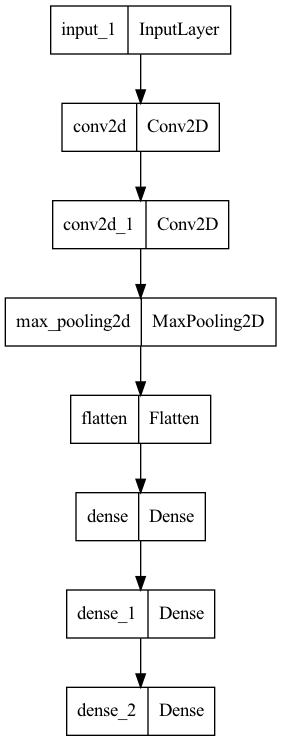

In [5]:
from tensorflow.keras.utils import plot_model

plot_model(trained_model, to_file="ex2_model.png")

In [4]:
help(plot_model)

Help on function plot_model in module keras.utils.vis_utils:

plot_model(model, to_file='model.png', show_shapes=False, show_dtype=False, show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96, layer_range=None, show_layer_activations=False)
    Converts a Keras model to dot format and save to a file.
    
    Example:
    
    ```python
    input = tf.keras.Input(shape=(100,), dtype='int32', name='input')
    x = tf.keras.layers.Embedding(
        output_dim=512, input_dim=10000, input_length=100)(input)
    x = tf.keras.layers.LSTM(32)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    model = tf.keras.Model(inputs=[input], outputs=[output])
    dot_img_file = '/tmp/model_1.png'
    tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)
    ```
    
    Args

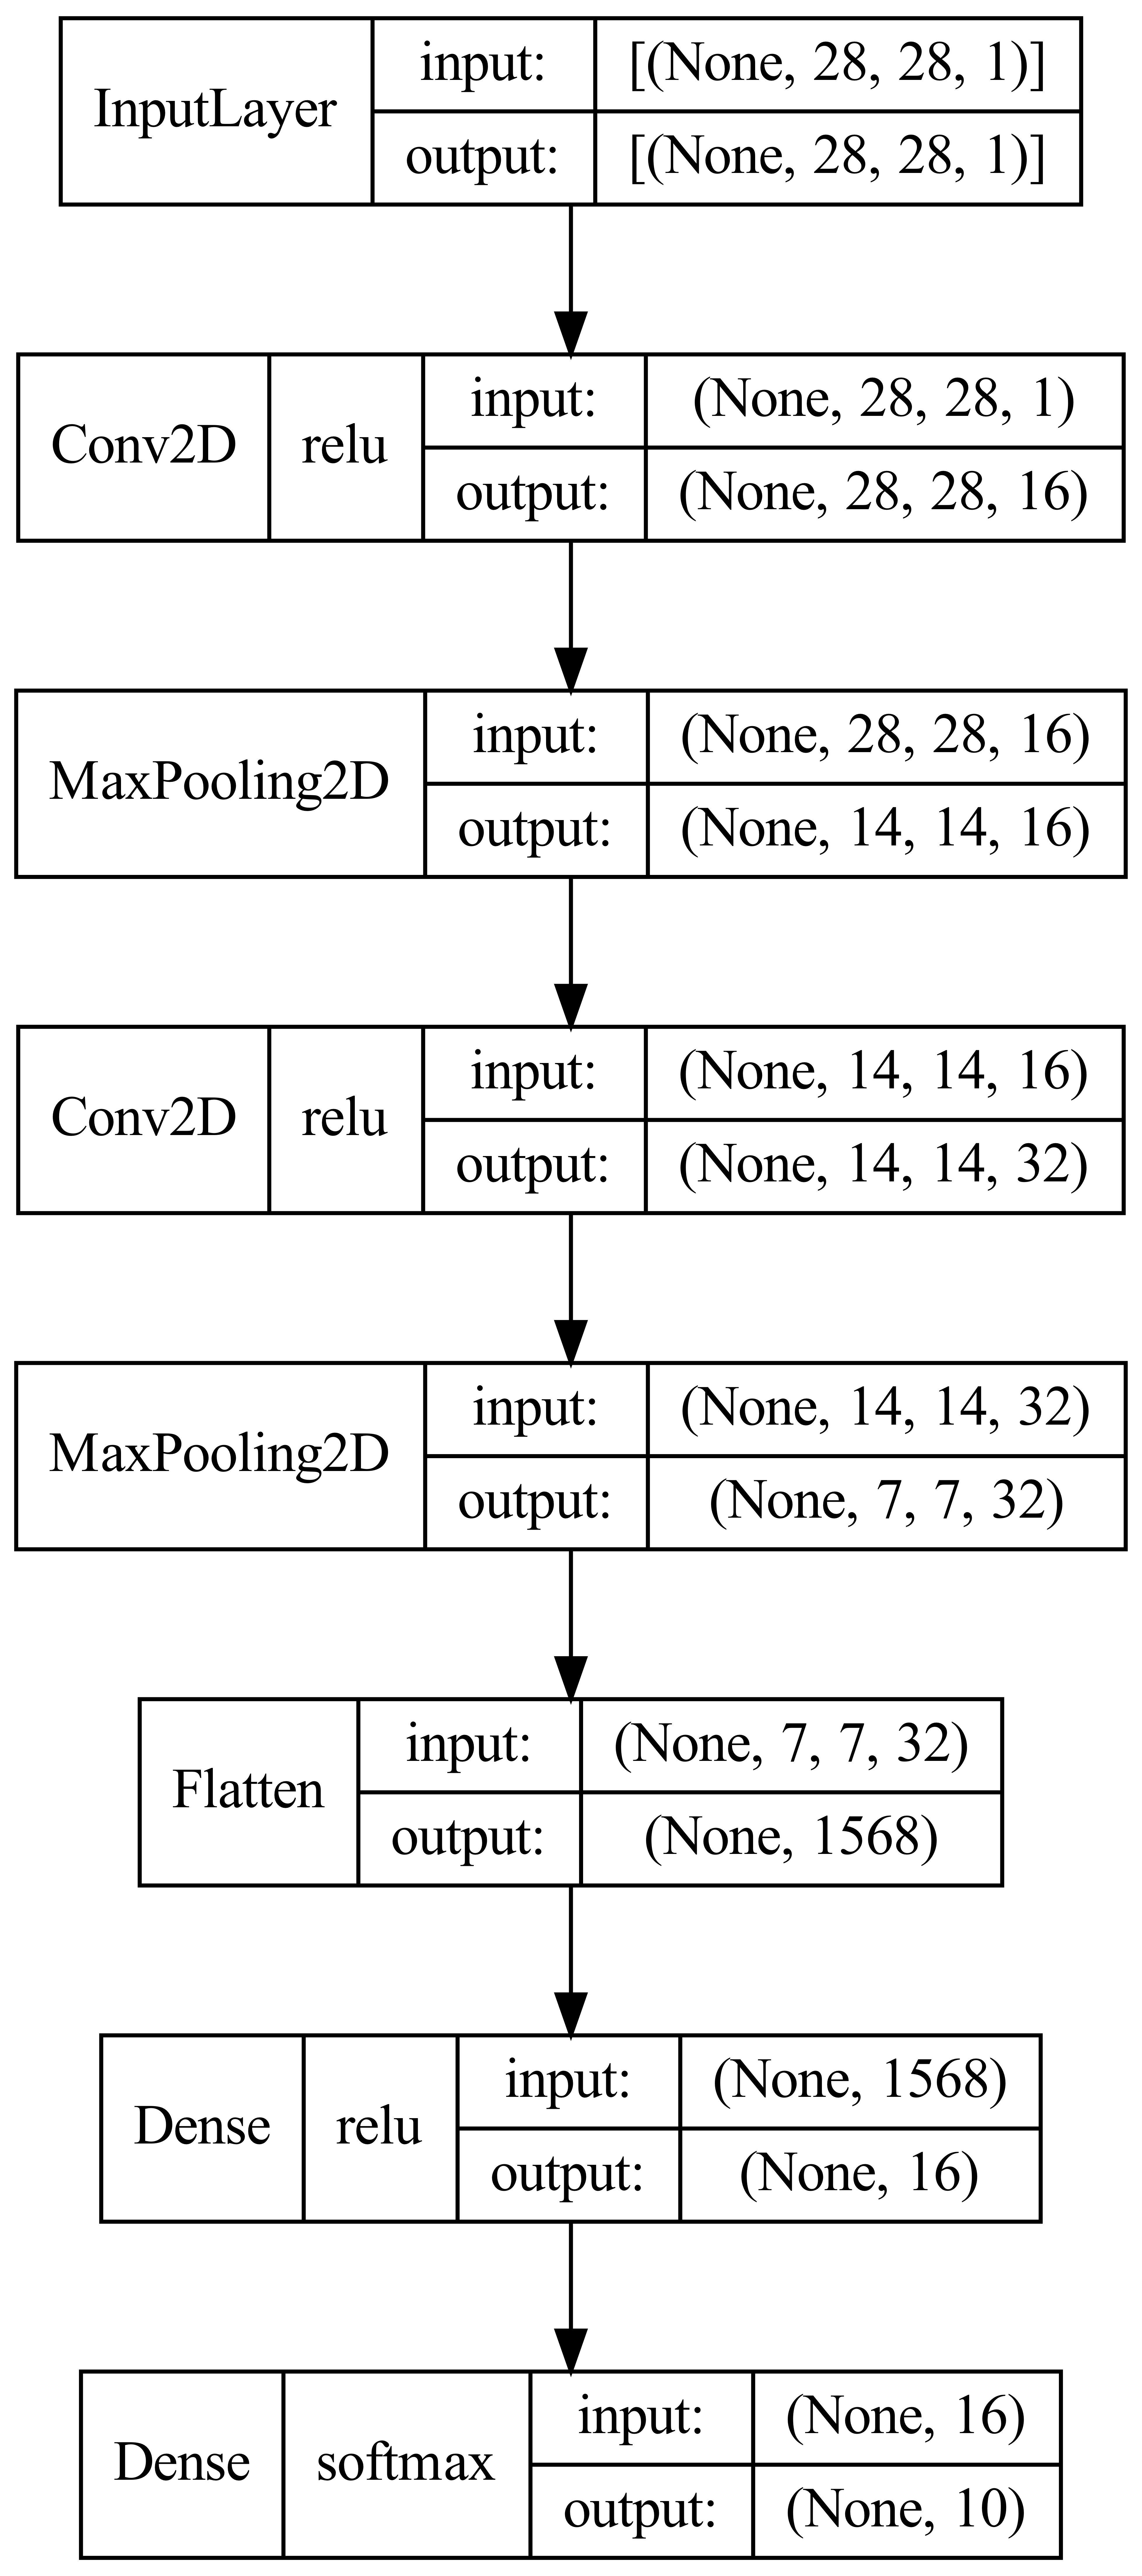

In [18]:
from tensorflow.keras.utils import plot_model

plot_model(trained_model, to_file="trained_model4.png", show_shapes=True, show_layer_names = False, dpi=1000, show_layer_activations=True, expand_nested=True)

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import numpy
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


predictions = trained_model.predict(x_test)
predicted_number = numpy.argmax(predictions, axis= 1)

matched = 0
not_matched = 0
for i in range(10000):
    if y_test[i] == predicted_number[i]:
        matched += 1
    else:
        not_matched += 1
print(f"matched numbers : {matched}")      
print(f"non matched numbers : {not_matched}")

313/313 [==============================] - 2s 4ms/step
matched numbers : 4077
non matched numbers : 5923


In [11]:
help(plt.savefig)

Help on function savefig in module matplotlib.pyplot:

savefig(*args, **kwargs)
    Save the current figure.
    
    Call signature::
    
      savefig(fname, *, dpi='figure', format=None, metadata=None,
              bbox_inches=None, pad_inches=0.1,
              facecolor='auto', edgecolor='auto',
              backend=None, **kwargs
             )
    
    The available output formats depend on the backend being used.
    
    Parameters
    ----------
    fname : str or path-like or binary file-like
        A path, or a Python file-like object, or
        possibly some backend-dependent object such as
        `matplotlib.backends.backend_pdf.PdfPages`.
    
        If *format* is set, it determines the output format, and the file
        is saved as *fname*.  Note that *fname* is used verbatim, and there
        is no attempt to make the extension, if any, of *fname* match
        *format*, and no extension is appended.
    
        If *format* is not set, then the format is inf

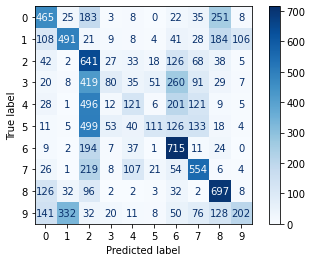

In [9]:
y_pred = predicted_number
y_test = y_test
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.savefig("ex2_confusion_matrix.svg", dpi=1000)
plt.show()

In [14]:
help(disp)

Help on ConfusionMatrixDisplay in module sklearn.metrics._plot.confusion_matrix object:

class ConfusionMatrixDisplay(builtins.object)
 |  ConfusionMatrixDisplay(confusion_matrix, *, display_labels=None)
 |  
 |  Confusion Matrix visualization.
 |  
 |  It is recommend to use
 |  :func:`~sklearn.metrics.ConfusionMatrixDisplay.from_estimator` or
 |  :func:`~sklearn.metrics.ConfusionMatrixDisplay.from_predictions` to
 |  create a :class:`ConfusionMatrixDisplay`. All parameters are stored as
 |  attributes.
 |  
 |  Read more in the :ref:`User Guide <visualizations>`.
 |  
 |  Parameters
 |  ----------
 |  confusion_matrix : ndarray of shape (n_classes, n_classes)
 |      Confusion matrix.
 |  
 |  display_labels : ndarray of shape (n_classes,), default=None
 |      Display labels for plot. If None, display labels are set from 0 to
 |      `n_classes - 1`.
 |  
 |  Attributes
 |  ----------
 |  im_ : matplotlib AxesImage
 |      Image representing the confusion matrix.
 |  
 |  text_ : nd

## Finding TP, TN, FP, FN for each class

In [20]:
import numpy as np


In [22]:
cm

array([[ 977,    1,    0,    1,    0,    1,    0,    0,    0,    0],
       [   0, 1133,    1,    0,    0,    0,    1,    0,    0,    0],
       [   3,    1, 1021,    1,    2,    0,    0,    3,    1,    0],
       [   0,    0,    3,  991,    0,    9,    0,    4,    3,    0],
       [   0,    0,    0,    0,  971,    0,    1,    2,    2,    6],
       [   4,    0,    0,    5,    0,  881,    2,    0,    0,    0],
       [   9,    2,    0,    1,    5,    5,  934,    0,    2,    0],
       [   0,    5,    9,    2,    0,    1,    0, 1007,    1,    3],
       [   6,    0,    3,    2,    2,    0,    1,    0,  958,    2],
       [   5,    3,    1,    4,   15,   11,    0,    1,    5,  964]])

### The True Positives are simply the diagonal elements:

In [31]:
TruePositive = np.diag(cm)
TruePositive

array([ 977, 1133, 1021,  991,  971,  881,  934, 1007,  958,  964])

### The False Positives are the sum of the respective column, minus the diagonal element:

In [25]:
FalsePositive = []
for i in range(10):
    FalsePositive.append(sum(cm[:,i]) - cm[i,i])
FalsePositive

[27, 12, 17, 16, 24, 27, 5, 10, 14, 11]

### Similarly, the False Negatives are the sum of the respective row, minus the diagonal element:

In [27]:
FalseNegative = []
for i in range(10):
    FalseNegative.append(sum(cm[i,:]) - cm[i,i])
FalseNegative

[3, 2, 11, 19, 11, 11, 24, 21, 16, 45]

### Now, the True Negatives are a little trickier; let's first think what exactly a True Negative means, with respect to, say class 0: it means all the samples that have been correctly identified as not being 0. So, essentially what we should do is remove the corresponding row & column from the confusion matrix, and then sum up all the remaining elements:

In [28]:
TrueNegative = []
for i in range(10):
    temp = np.delete(cm, i, 0)   # delete ith row
    temp = np.delete(temp, i, 1)  # delete ith column
    TrueNegative.append(sum(sum(temp)))
TrueNegative

[8993, 8853, 8951, 8974, 8994, 9081, 9037, 8962, 9012, 8980]

In [33]:
l = len(y_test)
for i in range(10):
    print(TruePositive[i] + FalsePositive[i] + FalseNegative[i] + TrueNegative[i] == l)
print(l)

True
True
True
True
True
True
True
True
True
True
10000


In [ ]:
from sklearn.metrics import